In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [34]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
test_data = datasets.MNIST('data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

Batch shape :  torch.Size([64, 1, 28, 28])
Labels shape :  torch.Size([64])


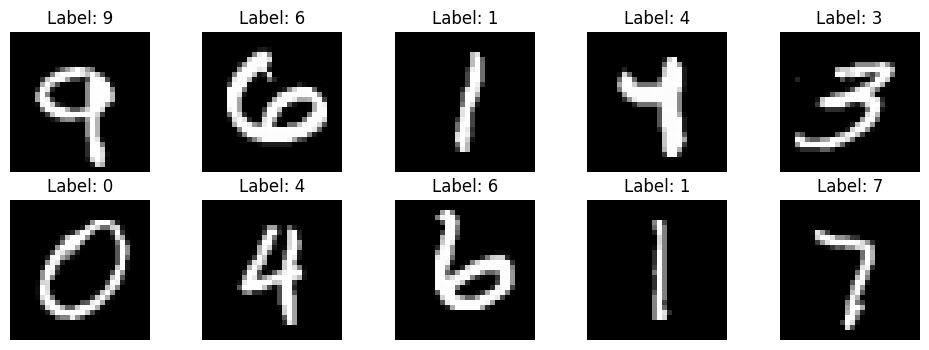

In [33]:
images, labels = next(iter(train_loader))
print('Batch shape : ', images.shape)
print('Labels shape : ', labels.shape)

fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i, axis in enumerate(axes.flat):
    axis.imshow(images[i].squeeze(), cmap='gray')
    axis.set_title(f'Label: {labels[i].item()}')
    axis.axis('off')

In [31]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=3, padding=1),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.Conv2d(6, 6, kernel_size=3, padding=1),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(6, 12, kernel_size=3, padding=1),
            nn.BatchNorm2d(12),
            nn.ReLU(),
            nn.Conv2d(12, 12, kernel_size=3, padding=1),
            nn.BatchNorm2d(12),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(12, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(12),
            nn.ReLU(),
            nn.Conv2d(24, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(12),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout2d(p=0.5),
            nn.LogSoftmax(dim=1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(24*6*6, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        x = self.features()
        return self.classifier(x)
    
model = MyCNN()
print(model)



MyCNN(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1